In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# a kaggle api token is free to generate, but you can also just download the dataset manually
USE_API = True

if USE_API:
    import kaggle

    kaggle.api.authenticate()

    kaggle.api.dataset_download_files(
        "aryarishabh/hand-gesture-recognition-dataset",
        path="./data",
        unzip=True
    )

TRAIN_PATH = './data/train/train'

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=4, width_shift_range=0.15, height_shift_range=0.2, shear_range=0.3, fill_mode='nearest', validation_split=0.25)

train_set = train_datagen.flow_from_directory(
    directory=TRAIN_PATH, class_mode='categorical', color_mode='grayscale', target_size=(64,64), batch_size=128, subset='training', shuffle=True)

validation_set = train_datagen.flow_from_directory(
    directory=TRAIN_PATH, target_size=(64,64), batch_size=64, class_mode='categorical', color_mode='grayscale', subset='validation', shuffle=True)


Dataset URL: https://www.kaggle.com/datasets/aryarishabh/hand-gesture-recognition-dataset
Found 13500 images belonging to 20 classes.
Found 4500 images belonging to 20 classes.


In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import MaxPooling2D, Flatten, Conv2D, Dense, Dropout

def make_model():
    model = Sequential(name='GestureRecognitionModel')

    # basic features: edges, corners, textures
    model.add(Conv2D(32, input_shape=(64,64,1), kernel_size=(3,3), strides=(1,1), activation='relu', padding='same', name='1-conv_features_1'))
    # doubles filters, compresses spatial size with stride 2
    model.add(Conv2D(64, kernel_size=(3,3), strides=(2,2), activation='relu', padding='same', name='1-conv_features_2'))
    # keeps strongest activations, halves spatial size
    model.add(MaxPooling2D(pool_size=(2,2), name='1-pool'))
    # 15% of neurons dropped to prevent overfitting
    model.add(Dropout(0.15, name='1-dropout'))

    # complex patterns: shapes, parts of objects
    model.add(Conv2D(64, kernel_size=(3,3), strides=(2,2), activation='relu', padding='same', name='2-conv_patters_1'))
    # high level combinations of patterns
    model.add(Conv2D(128, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same', name='2-conv_patters_2'))
    # spatial compression to retain the strongest signals
    model.add(MaxPooling2D(pool_size=(2,2), name='2-pool'))
    # 25% of neurons dropped to prevent overfitting
    model.add(Dropout(0.25, name='2-dropout'))

    # 3D feature maps into a 1D vector
    model.add(Flatten(name='3-flatten'))
    # learns combinations of extracted features
    model.add(Dense(64, activation='relu', name='3-dense_1'))
    # compresses further into a smaller representation
    model.add(Dense(32, activation='relu', name='3-dense_2'))
    # outputs layer: probability for each of the 20 classes
    model.add(Dense(20, activation='softmax', name='output'))
 
    model.compile(
          loss='categorical_crossentropy',
          optimizer='Adam', 
          metrics=['accuracy'])
    
    return model

In [4]:
model = make_model()
model.summary()

Model: "GestureRecognitionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 1-conv_features_1 (Conv2D)      │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1-conv_features_2 (Conv2D)      │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1-pool (MaxPooling2D)           │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1-dropout (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2-conv_patters_1 (Conv2D)       │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2-conv_patters_2 (Conv2D)       │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2-pool (MaxPooling2D)           │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2-dropout (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3-flatten (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3-dense_1 (Dense)               │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3-dense_2 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,476 (1.01 MB)

 Trainable params: 263,476 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
      train_set, validation_data=validation_set,
      epochs=20, steps_per_epoch=64, validation_steps=48,
      callbacks = [EarlyStopping(monitor='val_loss', patience=3, mode='auto')]
)

MODEL_PATH = './model/model.keras'

model.save(MODEL_PATH)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 931ms/step - accuracy: 0.3593 - loss: 1.9949 - val_accuracy: 0.7871 - val_loss: 0.6719
Epoch 2/20
42/64 ━━━━━━━━━━━━━━━━━━━━ 7s 324ms/step - accuracy: 0.8081 - loss: 0.5669

c:\Users\LS\OneDrive\Documents\Mózes anyagai\Project DDD\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 308ms/step - accuracy: 0.8495 - loss: 0.4502 - val_accuracy: 0.9300 - val_loss: 0.2263
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 296ms/step - accuracy: 0.9505 - loss: 0.1460 - val_accuracy: 0.9622 - val_loss: 0.1214
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9691 - loss: 0.1043 - val_accuracy: 0.9642 - val_loss: 0.1068
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.9777 - loss: 0.0803 - val_accuracy: 0.9840 - val_loss: 0.0521
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9879 - loss: 0.0361 - val_accuracy: 0.9883 - val_loss: 0.0447
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.9862 - loss: 0.0433 - val_accuracy: 0.9876 - val_loss: 0.0496
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9876 - val_loss: 0.0374
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9908 - loss: 0.0277 - val_accuracy: 0.9896 - va

<Figure size 640x480 with 0 Axes>

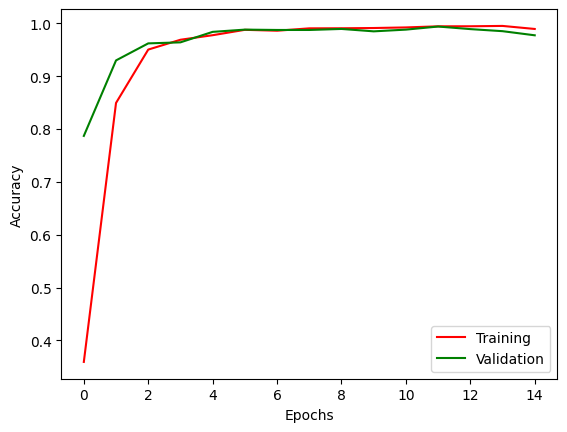

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt

accuracy        = history.history['accuracy']
val_accuracy    = history.history['val_accuracy']
loss            = history.history['loss']
val_loss        = history.history['val_loss']

epochs=range(len(accuracy))

plt.plot(epochs, accuracy, 'r', label='Training')
plt.plot(epochs, val_accuracy, 'g', label='Validation')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.figure()

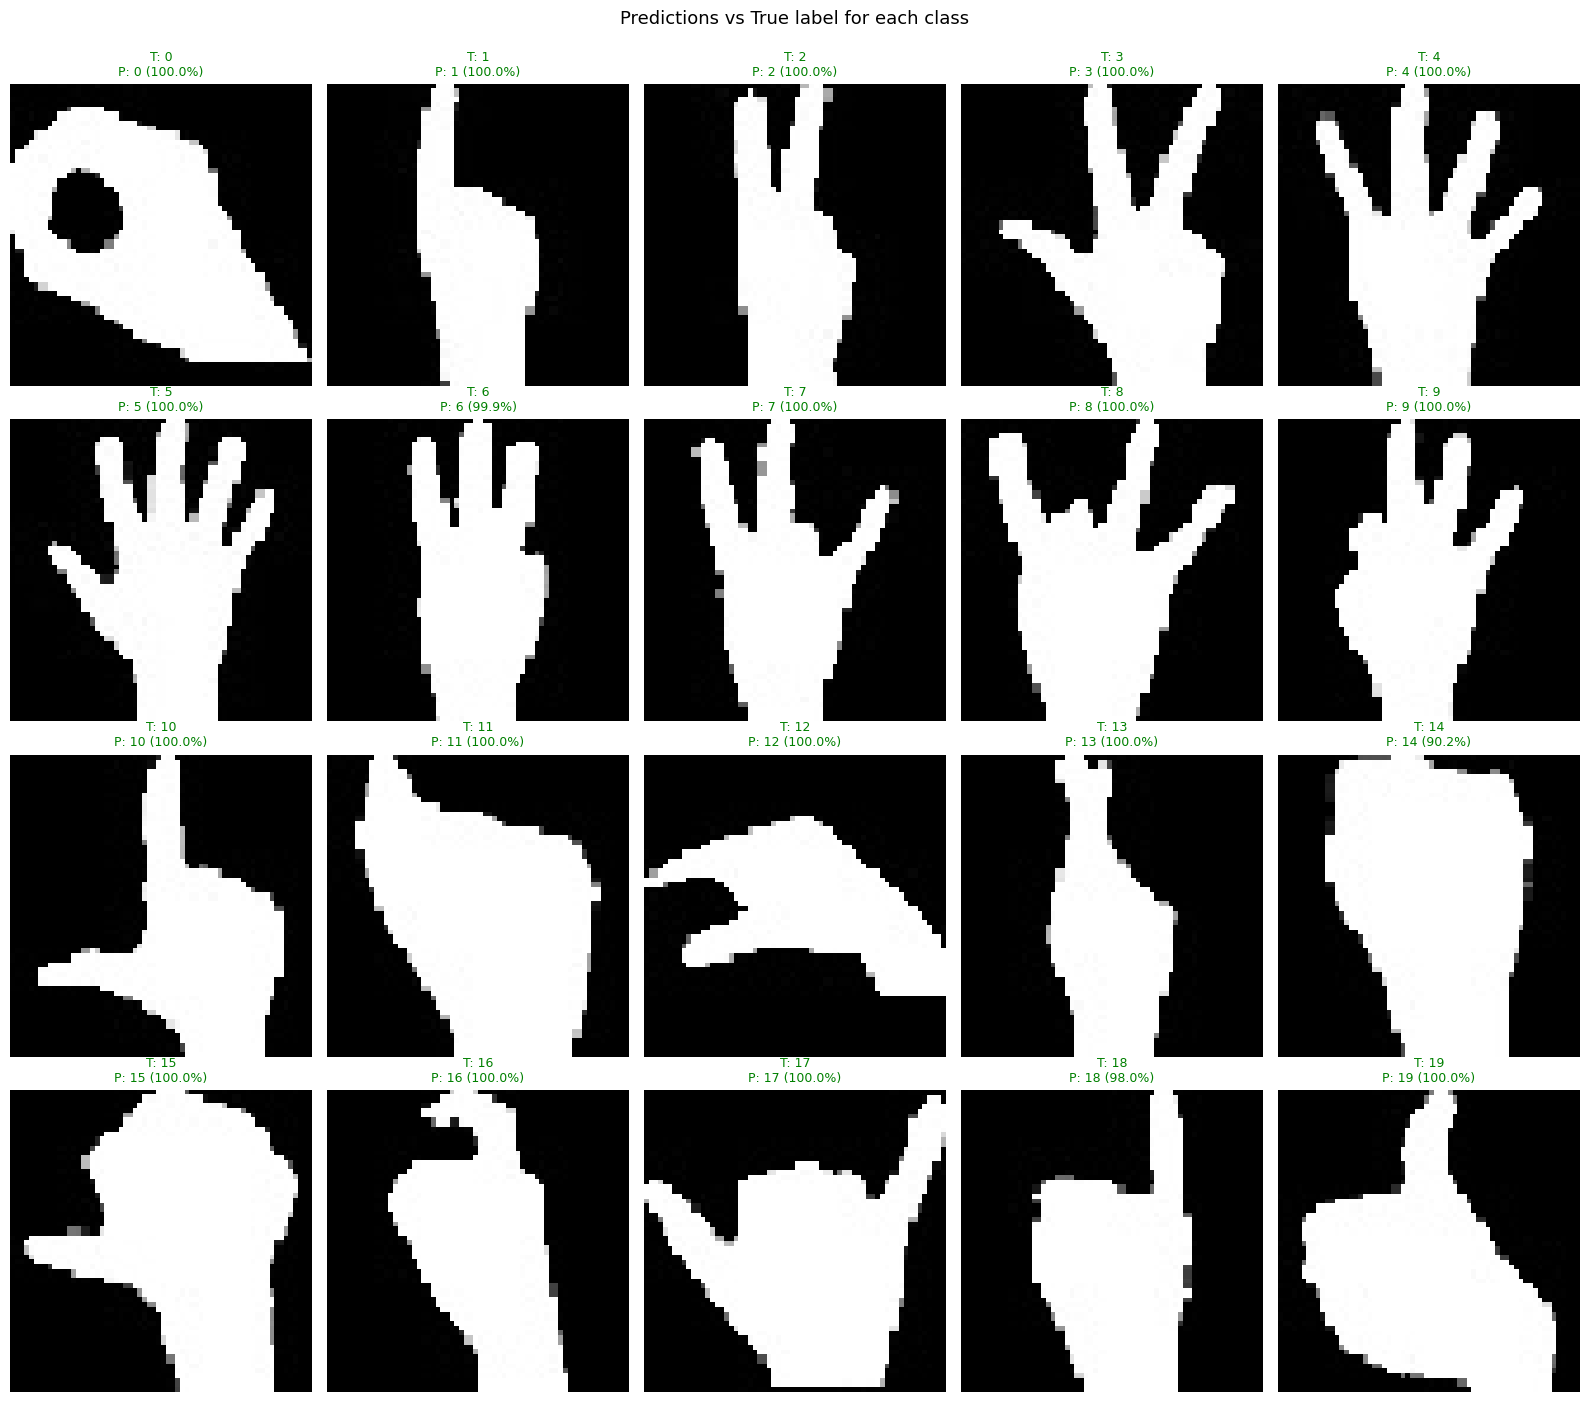

In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

TEST_PATH = './data/test/test'
IMG_SIZE = (64, 64)
CLASS_NAMES = list(train_set.class_indices.keys())

sample = []
class_folders = sorted([
    f for f in os.listdir(TEST_PATH)
    if os.path.isdir(os.path.join(TEST_PATH, f))
], key=lambda x: int(''.join(filter(str.isdigit, x))))

for class_folder in class_folders:
    folder_path = os.path.join(TEST_PATH, class_folder)
    images = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if images:
        img_file = random.choice(images)
        sample.append((os.path.join(folder_path, img_file), class_folder))

fig, axes = plt.subplots(4, 5, figsize=(16, 14))
axes = axes.flatten()

for ax, (img_path, true_label) in zip(axes, sample):
    img       = image.load_img(img_path, target_size=IMG_SIZE, color_mode="grayscale")
    img_array = image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    preds      = model.predict(img_input, verbose=0)
    pred_idx   = np.argmax(preds[0])
    pred_label = CLASS_NAMES[pred_idx]
    confidence = preds[0][pred_idx] * 100

    correct = pred_label == true_label
    color   = "green" if correct else "red"

    ax.imshow(img_array.squeeze(), cmap="gray")
    ax.set_title(f"T: {true_label}\nP: {pred_label} ({confidence:.1f}%)", fontsize=9, color=color)
    ax.axis("off")

plt.suptitle("Predictions vs True label for each class", fontsize=13, y=1)
plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

OUTPUT_TFLITE   = "./model/model.tflite"
OUTPUT_HEADER   = "./model/model.h"
QUANTIZE        = True

model = tf.keras.models.load_model(MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_keras_model(model)

if QUANTIZE:
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    def representative_dataset():
        for _ in range(100):
            import numpy as np
            sample = np.random.rand(1, 64, 64, 1).astype(np.float32)
            yield [sample]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.uint8
    converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

with open(OUTPUT_TFLITE, "wb") as f:
    f.write(tflite_model)
size_kb = os.path.getsize(OUTPUT_TFLITE) / 1024
print(f"TFLite model saved: {OUTPUT_TFLITE} ({size_kb:.1f} KB)")

with open(OUTPUT_TFLITE, "rb") as f:
    data = f.read()

hex_array = ", ".join(f"0x{b:02x}" for b in data)
bytes_list = [f"0x{b:02x}" for b in data]
lines = []
for i in range(0, len(bytes_list), 12):
    lines.append("  " + ", ".join(bytes_list[i:i+12]))
hex_lines = ",\n".join(lines)

header = f"""// Model: {OUTPUT_TFLITE}  |  Size: {len(data)} bytes
#ifndef MODEL_H
#define MODEL_H

const unsigned char model_data[] = {{
{hex_lines}
}};
const unsigned int model_data_len = {len(data)};

#endif  // MODEL_H"""

with open(OUTPUT_HEADER, "w") as f:
    f.write(header)
print(f"Header file saved: {OUTPUT_HEADER} ({len(data):,} bytes)")

INFO:tensorflow:Assets written to: C:\Users\LS\AppData\Local\Temp\tmp6hvjc072\assets


INFO:tensorflow:Assets written to: C:\Users\LS\AppData\Local\Temp\tmp6hvjc072\assets


Saved artifact at 'C:\Users\LS\AppData\Local\Temp\tmp6hvjc072'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  1974838556048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838557008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838556624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838553552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838554512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838554128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838555664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838555088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838552592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1974838558544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19748385

c:\Users\LS\OneDrive\Documents\Mózes anyagai\Project DDD\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model saved: ./model/model.tflite (276.0 KB)
Header file saved: ./model/model.h (282,640 bytes)
